# Localization Operations Analytics

This notebook analyses project delivery, client demand, translator coverage and quality performance for a simulated localization service provider.

## Report Structure

1. Executive Summary
2. Project Performance
3. Client Insights
4. Translator and Resource Insights
5. Quality Insights
6. Conclusions
7. Operational Appendix

In [668]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd


PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analytics.database import get_connection

In [669]:
from src.analytics.queries import list_queries, run_query


available_queries = list_queries()

print(f"{len(available_queries)} named queries available.")

53 named queries available.


# Executive Summary

The executive summary provides a high-level overview of project volume, current workload, delivery risk, turnaround time and quality performance.

In [670]:
project_status = run_query("project_status_summary")
turnaround_summary = run_query("average_project_turnaround")
overdue_summary = run_query("active_overdue_project_count")
qa_summary = run_query("overall_qa_summary")

In [671]:
total_projects = int(project_status["project_count"].sum())

completed_projects = int(
    project_status.loc[
        project_status["status"] == "Completed",
        "project_count",
    ].sum()
)

active_projects = int(
    project_status.loc[
        project_status["status"].isin(["In Translation", "QA"]),
        "project_count",
    ].sum()
)

overdue_projects = int(
    overdue_summary.loc[0, "overdue_project_count"]
)

average_turnaround = float(
    turnaround_summary.loc[0, "average_turnaround_days"]
)

average_qa_score = float(
    qa_summary.loc[0, "average_qa_score"]
)

qa_pass_rate = float(
    qa_summary.loc[0, "qa_pass_rate"]
)

active_overdue_rate = (
    overdue_projects / active_projects * 100
    if active_projects > 0
    else 0
)

completion_rate = (
    completed_projects / total_projects * 100
    if total_projects > 0
    else 0
)

print(f"Completion rate: {completion_rate:.1f}%")
print(f"Active overdue rate: {active_overdue_rate:.1f}%")

Completion rate: 63.5%
Active overdue rate: 9.3%


In [672]:
executive_summary = pd.DataFrame(
    {
        "Metric": [
            "Total Projects",
            "Completed Projects",
            "Active Projects",
            "Completion Rate",
            "Active Overdue Projects",
            "Active Overdue Rate",
            "Average Planned Turnaround",
            "Average QA Score",
            "QA Pass Rate",
        ],
        "Value": [
            f"{total_projects:,}",
            f"{completed_projects:,}",
            f"{active_projects:,}",
            f"{completion_rate:.1f}%",
            f"{overdue_projects:,}",
            f"{active_overdue_rate:.1f}%",
            f"{average_turnaround:.1f} days",
            f"{average_qa_score:.2f}",
            f"{qa_pass_rate:.1f}%",
        ],
    }
)

executive_summary

,Metric,Value
0,Total Projects,"2,500"
1,Completed Projects,"1,588"
2,Active Projects,753
3,Completion Rate,63.5%
4,Active Overdue Projects,70
5,Active Overdue Rate,9.3%
6,Average Planned Turnaround,9.2 days
7,Average QA Score,94.71
8,QA Pass Rate,80.6%


### Key Findings

- The dataset contains 2,500 localization projects, of which 1,588 (63.5%) have been completed.
- There are currently 753 active projects in production.
- Seventy active projects are overdue, representing 9.3% of the active workload.
- The average planned turnaround time across all projects is 9.2 days.
- QA performance is strong, with an average score of 94.71 and an overall pass rate of 80.6%.

### Business Impact

- The majority of recorded projects have been successfully completed, with almost two-thirds of all projects marked as complete.
- Less than 10% of active work is currently overdue, suggesting delivery risk is concentrated within a relatively small subset of projects.
- QA performance appears consistently high, with an average score of 94.71 and an 80.6% pass rate.

### Questions for Further Investigation

The executive summary provides an overview of current operational performance. The following sections investigate the underlying factors influencing these metrics, including project delivery, client demand, translator capacity and quality performance.

# Project Performance

This section examines project delivery performance across the localization operation.

The analyses focus on identifying delivery risk, understanding project turnaround times and evaluating how different project types contribute to operational workload.

## Business Question 1

### Which projects are overdue and are there any common factors?

Overdue projects represent one of the clearest indicators of delivery risk within a localization operation.

This analysis investigates whether overdue work is concentrated within particular project types or clients, helping identify patterns that may require operational attention.

### Methodology

This analysis investigates:

- Overall number of active overdue projects
- Overdue rate across project types
- Overdue rate across clients

Project-level overdue listings are included in the appendix.

### Active Overdue Projects

There are currently **70 active overdue projects**, representing **9.3%** of all active work.

### Overdue Rate by Project Type

The overdue rate compares the number of overdue projects with the total number of active projects within each project type.

In [673]:
overdue_by_type = run_query("overdue_rate_by_project_type")

overdue_by_type

,project_type,active_project_count,overdue_project_count,overdue_rate
0,Legal,130,16,12.3
1,Documentation,122,15,12.3
2,Marketing,110,12,10.9
3,Subtitles,124,11,8.9
4,Training,140,10,7.1
5,UI,127,6,4.7


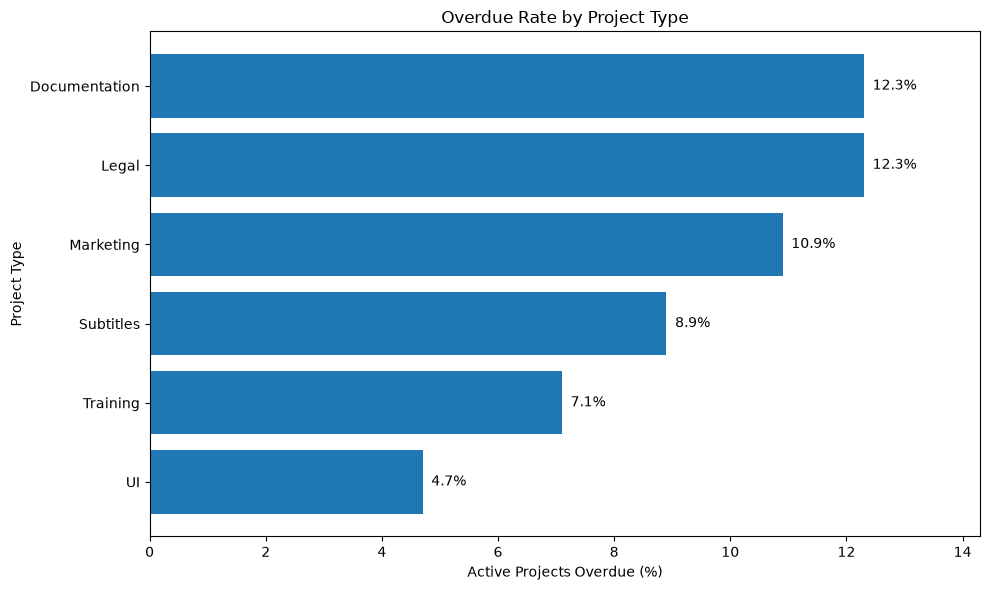

In [674]:
overdue_by_type_chart = overdue_by_type.sort_values(
    "overdue_rate",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    overdue_by_type_chart["project_type"],
    overdue_by_type_chart["overdue_rate"],
)

plt.title("Overdue Rate by Project Type")
plt.xlabel("Active Projects Overdue (%)")
plt.ylabel("Project Type")

for index, value in enumerate(overdue_by_type_chart["overdue_rate"]):
    plt.text(
        value + 0.15,
        index,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(
    0,
    overdue_by_type_chart["overdue_rate"].max() + 2
)

plt.tight_layout()
plt.show()

#### Key Findings

- Legal and Documentation have the highest overdue rates, with 12.3% of active projects overdue in both categories.
- Marketing has the next-highest overdue rate at 10.9%.
- UI has the lowest overdue rate at 4.7%, less than half the rate recorded for Legal and Documentation.
- Active workloads are reasonably similar across project types, ranging from 110 to 140 projects. This suggests that differences in overdue rates are not explained by project volume alone.

#### Business Impact

- Legal, Documentation and Marketing projects may require closer monitoring because a greater proportion of their active workload is overdue.
- The variation between project types suggests that delivery risk is not evenly distributed across the project portfolio.
- Reviewing factors such as project size, planned turnaround, resource availability and QA requirements may help explain why some project types experience more delays than others.

### Overdue Rate by Client

Client overdue rates show whether delayed work is concentrated among particular client accounts.

Only the ten clients with the highest overdue rates are shown in the chart to keep the comparison readable. The complete client-level results remain available in the query output.

In [675]:
overdue_by_client = run_query("overdue_rate_by_client")

overdue_by_client

,client,active_project_count,overdue_project_count,overdue_rate
0,Salesforce,28,5,17.9
1,Baker McKenzie,30,5,16.7
2,Uber,26,4,15.4
3,Nintendo,20,3,15.0
4,Coursera,28,4,14.3
5,Pfizer,21,3,14.3
6,SAP,21,3,14.3
7,Airbnb,36,5,13.9
8,Disney,22,3,13.6
9,Booking.com,27,3,11.1


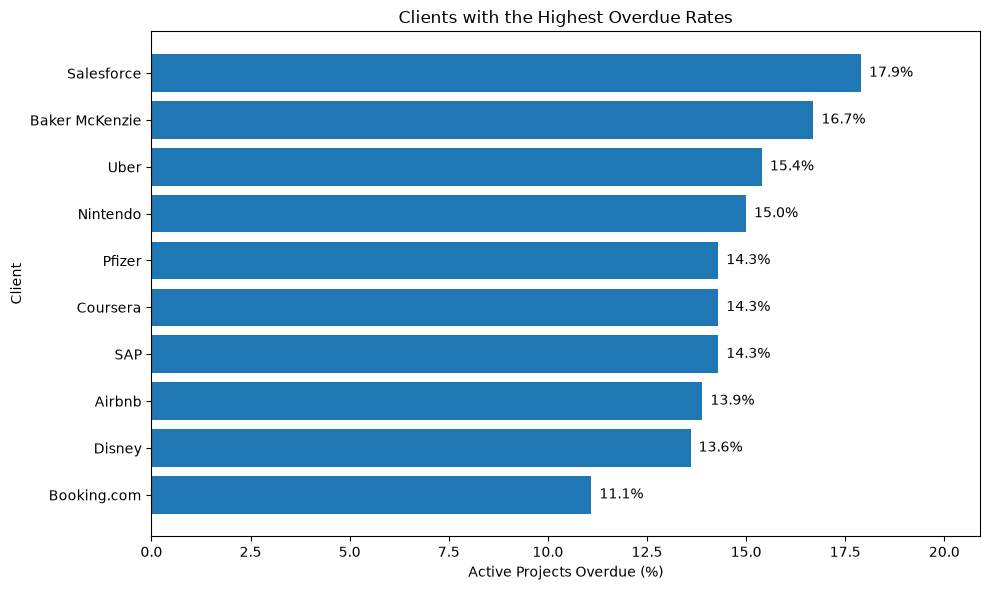

In [676]:
top_overdue_clients = (
    overdue_by_client
    .head(10)
    .sort_values("overdue_rate", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_overdue_clients["client"],
    top_overdue_clients["overdue_rate"],
)

plt.title("Clients with the Highest Overdue Rates")
plt.xlabel("Active Projects Overdue (%)")
plt.ylabel("Client")

for index, value in enumerate(top_overdue_clients["overdue_rate"]):
    plt.text(
        value + 0.2,
        index,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(
    0,
    top_overdue_clients["overdue_rate"].max() + 3
)

plt.tight_layout()
plt.show()

#### Key Findings

- Salesforce has the highest overdue rate, with 17.9% of its active projects overdue.
- Baker McKenzie follows with an overdue rate of 16.7%.
- Uber and Nintendo also have overdue rates of at least 15%.
- Salesforce and Baker McKenzie each have five overdue projects, the highest overdue count among the clients with the greatest overdue rates.
- The portfolio-wide active overdue rate is 9.3%, meaning each of the ten clients shown performs above the overall rate.

#### Business Impact

- Clients with the highest overdue rates may require closer delivery monitoring and earlier intervention when deadlines are at risk.
- Repeated delays for the same client could affect client satisfaction and place additional pressure on project managers and delivery teams.
- Further analysis is needed to determine whether these clients request particular project types, larger projects or shorter delivery times more frequently.

### Summary

There are 70 active overdue projects, representing 9.3% of the active workload.

Overdue work is not evenly distributed across the portfolio. Legal and Documentation have the highest overdue rates by project type, while Salesforce and Baker McKenzie have the highest rates at client level.

These results identify where delayed work is concentrated, but they do not establish the cause of those delays. Later analyses will compare turnaround times, project size, target locales and QA requirements to investigate whether these factors may contribute to the differences observed.

## Business Question 2

### What is the average turnaround time by project type and client?

Planned turnaround time shows how much time is allocated to complete different types of work. Comparing turnaround times across project types and clients helps identify where longer delivery windows are normally required and supports more informed project planning.

#### Methodology

Planned turnaround is calculated as the number of calendar days between a project's start date and due date.

The analysis compares average planned turnaround across:

- Project types
- Clients

These figures represent the time originally allocated to projects. They do not measure the actual time taken to complete the work.

### Average Turnaround by Project Type

This comparison shows whether different categories of localization work are routinely allocated different delivery windows.

In [677]:
turnaround_by_type = run_query(
    "average_turnaround_by_project_type"
)

turnaround_by_type

,project_type,average_turnaround_days
0,Documentation,17.7
1,Legal,13.2
2,Training,9.8
3,Marketing,6.7
4,UI,4.5
5,Subtitles,3.0


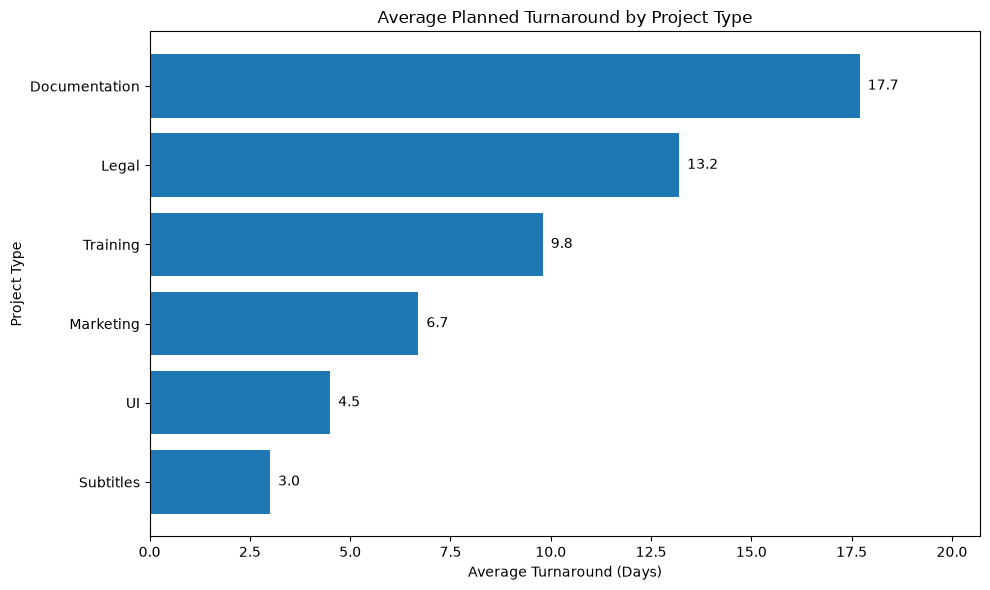

In [678]:
turnaround_by_type_chart = turnaround_by_type.sort_values(
    "average_turnaround_days",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    turnaround_by_type_chart["project_type"],
    turnaround_by_type_chart["average_turnaround_days"]
)

plt.title("Average Planned Turnaround by Project Type")
plt.xlabel("Average Turnaround (Days)")
plt.ylabel("Project Type")

for index, value in enumerate(
    turnaround_by_type_chart["average_turnaround_days"]
):
    plt.text(
        value + 0.2,
        index,
        f"{value:.1f}",
        va="center"
    )

plt.xlim(
    0,
    turnaround_by_type_chart[
        "average_turnaround_days"
    ].max() + 3
)

plt.tight_layout()
plt.show()

#### Key Findings

- Documentation projects have the longest average planned turnaround at approximately 17.7 days.
- Legal projects have the second-longest average turnaround at approximately 13.2 days.
- Training projects have an average planned turnaround of 9.8 days.
- Marketing, UI and Subtitle projects are allocated considerably shorter delivery windows.
- Subtitle projects have the shortest average turnaround at approximately 3 days.
- Documentation and Legal also recorded the highest overdue rates in the previous analysis. This shows an association between longer planned turnaround and higher overdue rates within the dataset, although it does not prove that longer delivery windows cause delays.

#### Business Impact

- Documentation and Legal projects are likely to require earlier planning because they are routinely allocated longer delivery windows.
- Longer planned turnaround may reflect factors such as larger project scope, more complex content or greater coordination requirements.
- The combination of longer turnaround times and higher overdue rates suggests that these project types may benefit from closer progress monitoring throughout delivery.
- Further analysis of word count, target locales and QA review time will help determine whether these projects also require greater operational effort.

### Average Turnaround by Client

Average turnaround by client helps identify whether some client accounts are routinely associated with longer planned delivery windows.

Only the ten clients with the longest average turnaround times are shown in the chart to keep the comparison readable. The full client-level results remain available in the query output.

In [679]:
turnaround_by_client = run_query(
    "average_turnaround_by_client"
)

turnaround_by_client

,client,project_count,average_turnaround_days
0,Pfizer,69,10.9
1,Barclays,82,10.1
2,Roche,71,10.1
3,Disney,79,10.0
4,Microsoft,92,10.0
5,Lego,80,9.8
6,Toyota,74,9.8
7,Nike,92,9.6
8,Netflix,102,9.5
9,Uber,75,9.5


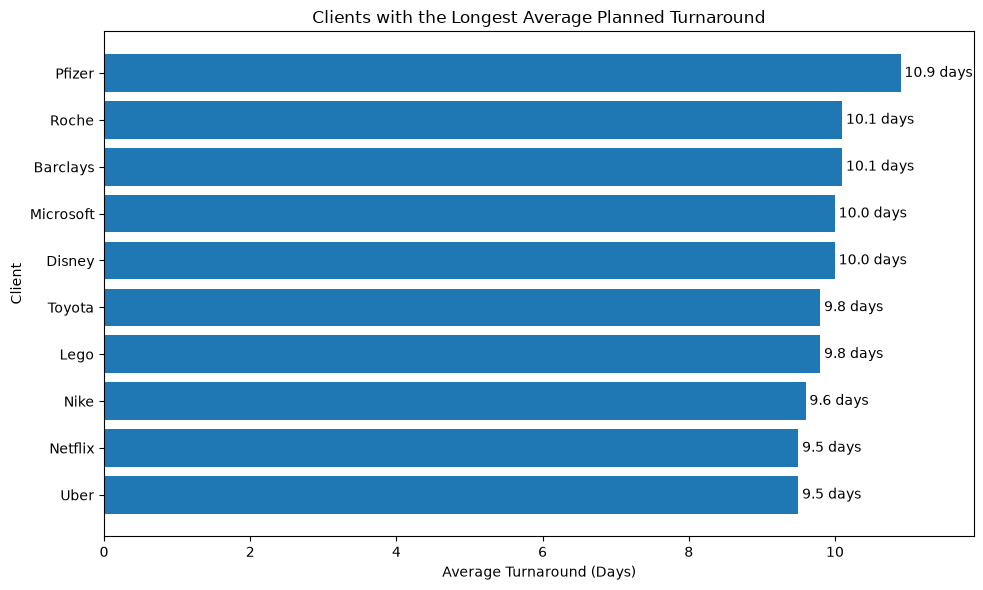

In [680]:
top_turnaround_clients = (
    turnaround_by_client
    .sort_values(
        "average_turnaround_days",
        ascending=False
    )
    .head(10)
    .sort_values(
        "average_turnaround_days",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_turnaround_clients["client"],
    top_turnaround_clients["average_turnaround_days"]
)

plt.title("Clients with the Longest Average Planned Turnaround")
plt.xlabel("Average Turnaround (Days)")
plt.ylabel("Client")

for index, value in enumerate(
    top_turnaround_clients["average_turnaround_days"]
):
    plt.text(
        value + 0.05,
        index,
        f"{value:.1f} days",
        va="center"
    )

plt.xlim(
    0,
    top_turnaround_clients[
        "average_turnaround_days"
    ].max() + 1
)

plt.tight_layout()
plt.show()

#### Key Findings

- Average planned turnaround varies less between clients than it does between project types.
- The clients shown in the chart have average turnaround times of approximately 9 to 10 days.
- Siemens and HSBC have the longest average planned turnaround at approximately 9.9 days.
- Booking.com follows closely with an average of approximately 9.8 days.
- Even the clients with the longest average turnaround remain well below the average recorded for Documentation projects.
- This suggests that project type has a stronger relationship with planned turnaround than client account alone.

#### Business Impact

- The relatively small differences between client averages suggest that client identity alone may not be the main factor determining planned turnaround.
- Differences in the mix of project types requested by each client may explain some of the variation between accounts.
- Client-level averages can still support workload forecasting, particularly for accounts that regularly require longer delivery windows.

### Summary

Planned turnaround differs substantially by project type. Documentation and Legal projects are allocated the longest delivery windows, while UI and Subtitle projects have much shorter planned turnaround times.

The differences between clients are considerably smaller. The clients with the longest average turnaround generally fall within a narrow range of approximately 9 to 10 days.

This suggests that project type is more closely associated with planned turnaround than client account alone. However, the types of projects requested by each client may still influence their overall average.

These findings will be used in the next analysis, which compares turnaround with project size, target locales and QA review time to assess which project types require the most effort.

## Business Question 3

### Which project types require the most effort?

Not all localization projects demand the same level of operational effort. Some require more coordination, involve larger volumes of content or take longer to review before delivery.

Understanding these differences helps support more accurate project planning and resource allocation.

#### Methodology

Project effort is assessed using four operational measures:

- Average planned turnaround
- Average word count
- Average number of target locales
- Average QA review time

Together, these metrics provide a broader view of operational effort and help identify which characteristics contribute most to differences between project types.

### Average Word Count by Project Type

Average word count provides an indication of the amount of content translated within each project type.

In [681]:
word_count = run_query(
    "average_word_count_by_project_type"
)

word_count

,project_type,average_word_count
0,Documentation,30158.0
1,Legal,17420.0
2,Training,11414.0
3,Marketing,6495.0
4,Subtitles,2562.0
5,UI,1630.0


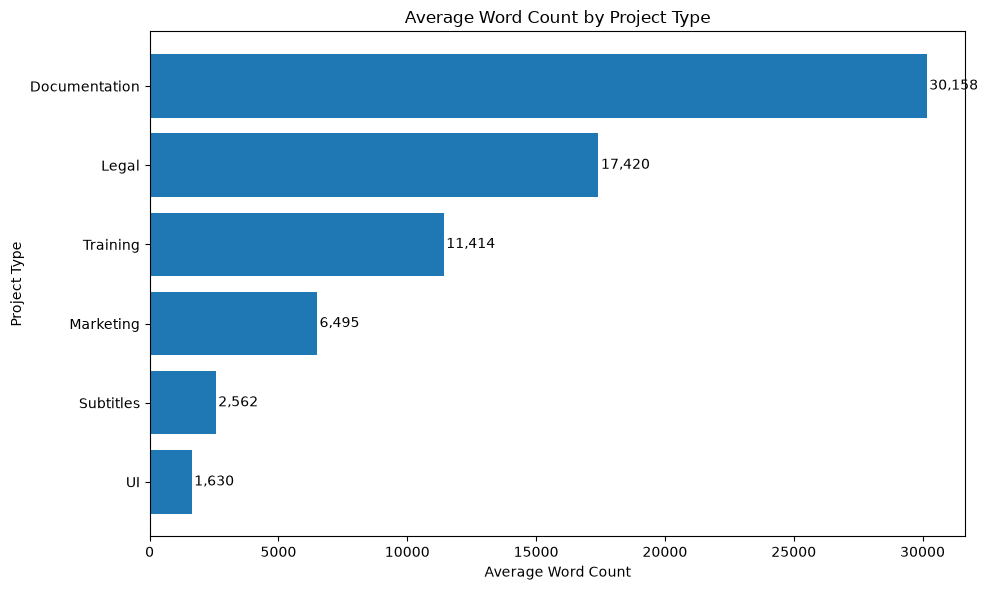

In [682]:
word_count_chart = word_count.sort_values(
    "average_word_count",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    word_count_chart["project_type"],
    word_count_chart["average_word_count"]
)

plt.title("Average Word Count by Project Type")
plt.xlabel("Average Word Count")
plt.ylabel("Project Type")

for i, value in enumerate(word_count_chart["average_word_count"]):
    plt.text(
        value + 100,
        i,
        f"{value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

#### Key Findings

- Documentation projects have by far the highest average word count at approximately **30,200 words**, almost twice that of Legal projects.
- Legal projects have the second-highest average word count at approximately **17,400 words**.
- Training projects average around **11,400 words**, while Marketing, Subtitles and UI projects contain substantially less content.
- UI projects have the smallest average word count at approximately **1,600 words**.
- The ranking closely mirrors the turnaround analysis from the previous section, suggesting that larger projects are generally allocated longer delivery windows.

#### Business Impact

- Documentation and Legal projects are likely to require greater translation effort due to their substantially larger content volumes.
- Larger projects may require additional planning, translator capacity and progress monitoring to support on-time delivery.
- Average word count appears to be a stronger indicator of project effort than project type alone.

### Average Target Locales by Project Type

The number of target locales provides an indication of coordination effort, as projects delivered into more languages generally require additional planning and resource management.

In [683]:
target_locales = run_query(
    "average_target_locales_by_project_type"
)

target_locales

,project_type,average_target_locales
0,Marketing,3.4
1,Training,3.2
2,Legal,3.2
3,UI,3.1
4,Subtitles,3.1
5,Documentation,3.0


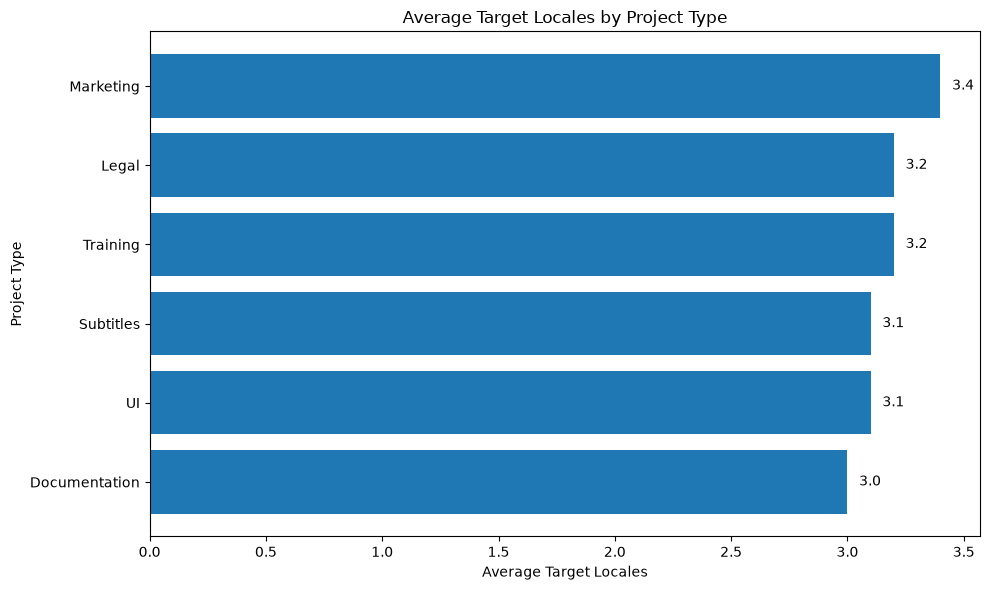

In [684]:
target_locales_chart = target_locales.sort_values(
    "average_target_locales",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    target_locales_chart["project_type"],
    target_locales_chart["average_target_locales"]
)

plt.title("Average Target Locales by Project Type")
plt.xlabel("Average Target Locales")
plt.ylabel("Project Type")

for i, value in enumerate(target_locales_chart["average_target_locales"]):
    plt.text(
        value + 0.05,
        i,
        f"{value:.1f}",
        va="center"
    )

plt.tight_layout()
plt.show()

#### Key Findings

- The average number of target locales varies only slightly between project types, ranging from **3.0 to 3.4 languages**.
- Marketing projects have the highest average number of target locales at **3.4**, although the difference is relatively small.
- Documentation projects have the lowest average at **3.0** target locales.
- Overall, language count remains remarkably consistent across the project portfolio.

#### Business Impact

- The small variation suggests that the number of target languages is not a major driver of operational differences between project types.
- Other characteristics, such as project size and planned turnaround, appear to have a greater influence on delivery effort within this dataset.

### Average QA Review Time by Project Type

QA review time represents the average effort required during quality assurance before delivery.

In [685]:
qa_review = run_query(
    "average_qa_review_time_by_project_type"
)

qa_review

,project_type,average_review_time_hours
0,Training,4.58
1,Marketing,4.54
2,Legal,4.50
3,UI,4.45


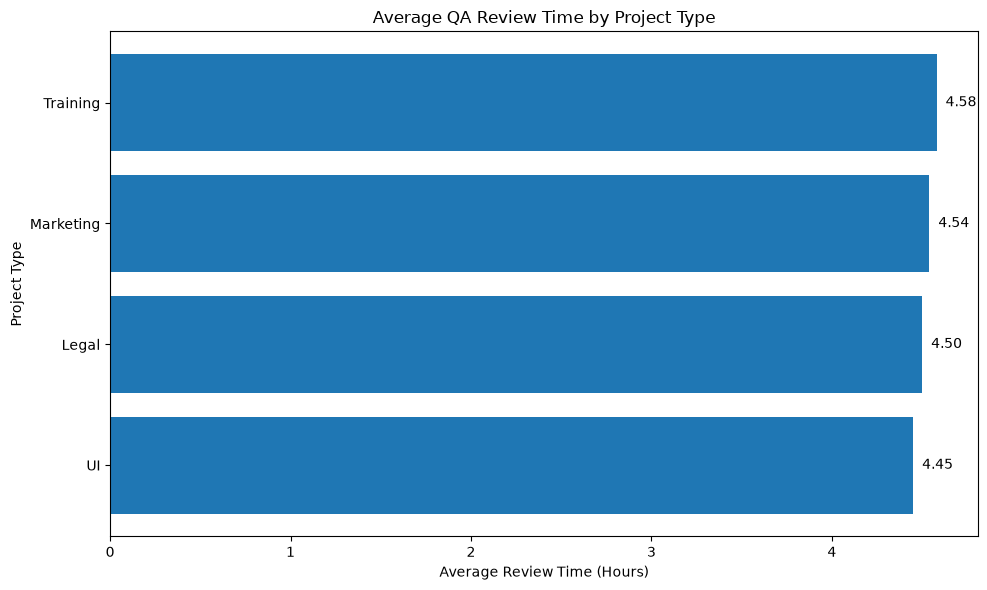

In [686]:
qa_review_chart = qa_review.sort_values(
    "average_review_time_hours",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    qa_review_chart["project_type"],
    qa_review_chart["average_review_time_hours"]
)

plt.title("Average QA Review Time by Project Type")
plt.xlabel("Average Review Time (Hours)")
plt.ylabel("Project Type")

for i, value in enumerate(
    qa_review_chart["average_review_time_hours"]
):
    plt.text(
        value + 0.05,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

#### Key Findings

- Average QA review time is highly consistent across project types, ranging from **4.45 to 4.58 hours**.
- Training projects require the longest average QA review time at **4.58 hours**.
- UI projects have the shortest average review time at **4.45 hours**.
- The differences between project types are minimal, indicating that QA effort is broadly similar regardless of project type.

#### Business Impact

- Quality assurance effort appears to be relatively stable across the project portfolio.
- Unlike turnaround time or project size, QA review time does not appear to distinguish more operationally demanding project types.
- This consistency suggests that QA resource requirements can be planned relatively uniformly across different categories of work.

### Overall Findings

The analyses suggest that project effort is primarily driven by project size rather than the number of target languages or QA review effort.

Documentation projects consistently rank highest across several operational measures. They have the longest planned turnaround times, the largest average word counts and one of the highest overdue rates, indicating they represent the most operationally demanding project type within the simulated dataset.

Legal projects display a similar pattern, although at a lower level than Documentation projects. In contrast, UI and Subtitle projects consistently have shorter planned turnaround times and substantially smaller average word counts.

While average target locales and QA review time remain relatively consistent across project types, project size and delivery duration vary considerably. These findings suggest that content volume is the strongest indicator of operational effort in this simulated localization portfolio.

# 3. Client Insights

This section examines client demand across the localization operation.

The analyses focus on understanding which clients generate the greatest operational workload by comparing project volume, translation volume, turnaround times and the types of localization work requested. Together, these measures provide a broader view of client demand and support informed resource planning and operational decision-making.


## Business Question

### Which clients place the greatest operational demand on the business?

Client demand cannot be assessed using project count alone. A client may submit a relatively small number of large projects, generate projects with longer turnaround times, or account for a disproportionate share of overdue work.

This analysis considers:

- Number of projects
- Total word volume
- Average project size
- Share of overall word volume
- Average turnaround time
- Active overdue rate
- Project-type mix

Together, these measures provide a broader view of which clients create the greatest demand on operational resources.

In [687]:
client_word_volume = run_query(
    "client_word_volume"
)

average_turnaround_by_client = run_query(
    "average_turnaround_by_client"
)

client_project_type_breakdown = run_query(
    "client_project_type_breakdown"
)

### Project Volume by Client

Project count shows how frequently each client generates work for the localization operation.

The chart below compares the ten clients with the highest number of projects.

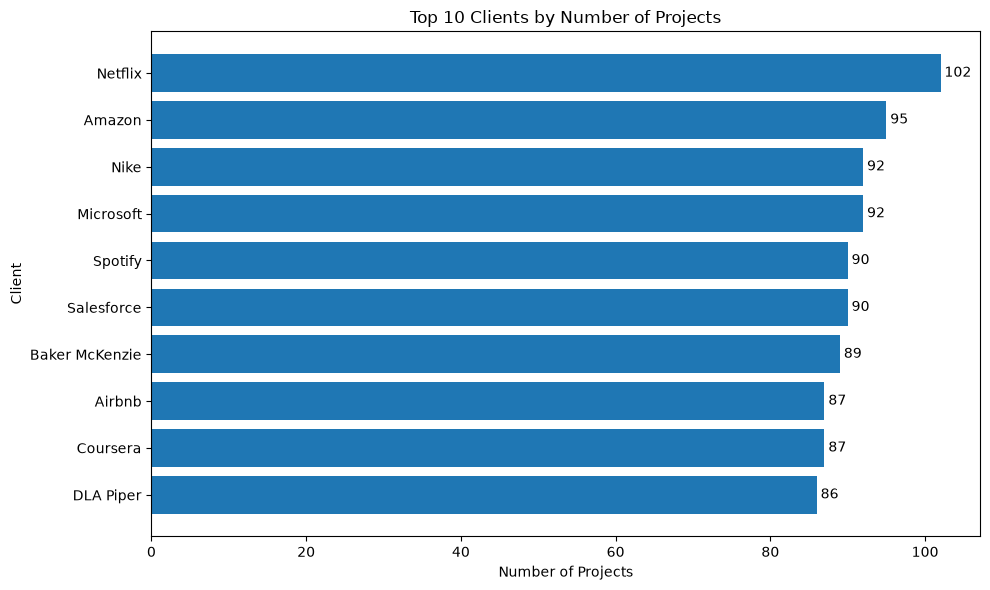

In [688]:
top_clients_by_project_count = (
    client_word_volume
    .nlargest(10, "project_count")
    .sort_values("project_count")
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_clients_by_project_count["client_name"],
    top_clients_by_project_count["project_count"]
)

ax.set_title(
    "Top 10 Clients by Number of Projects"
)
ax.set_xlabel(
    "Number of Projects"
)
ax.set_ylabel(
    "Client"
)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

#### Key Findings

- Netflix generated the highest number of projects, with 102 projects.
- Amazon followed with 95 projects.
- Microsoft and Nike each generated 92 projects.
- Salesforce generated 90 projects.
- Project activity is distributed across several major clients rather than being dominated by a single account.

#### Business Insight

Clients with a high project count create frequent operational activity, including project setup, assignment, monitoring and delivery.

However, project count does not account for project size. A client submitting many small projects may generate less translation work than a client submitting fewer but substantially larger projects. Project volume should therefore be considered alongside total word volume.

### Translation Workload by Client

Total word volume provides a broader measure of the translation workload generated by each client.

The chart below compares the ten clients responsible for the greatest total number of source words.

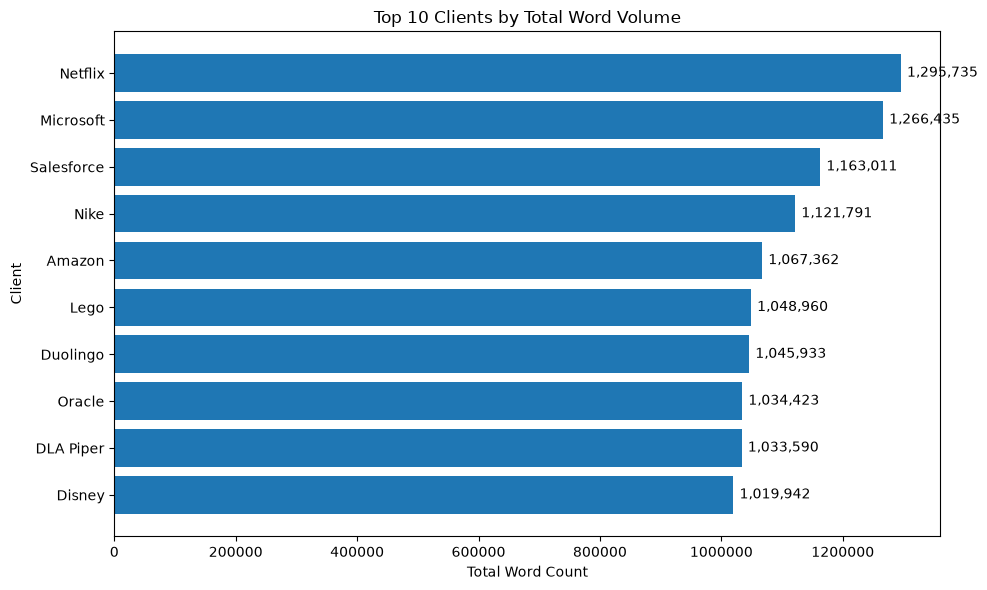

In [689]:
top_clients_by_word_volume = (
    client_word_volume
    .nlargest(10, "total_word_count")
    .sort_values("total_word_count")
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_clients_by_word_volume["client_name"],
    top_clients_by_word_volume["total_word_count"]
)

ax.set_title(
    "Top 10 Clients by Total Word Volume"
)
ax.set_xlabel(
    "Total Word Count"
)
ax.set_ylabel(
    "Client"
)

ax.ticklabel_format(
    style="plain",
    axis="x"
)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 10000,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center"
    )

plt.tight_layout()
plt.show()

#### Key Findings

- Netflix generated the greatest translation workload, with approximately 1.30 million words.
- Microsoft followed closely with approximately 1.27 million words.
- Amazon had the second-highest project count but ranked fifth by total word volume, with approximately 1.07 million words.

#### Business Insight

Project frequency and total translation workload do not produce exactly the same client ranking.

Amazon generated more projects than Microsoft, Salesforce and Nike, but produced a lower total word volume. This suggests that Amazon submitted a greater number of comparatively smaller projects.

Microsoft generated fewer projects than Amazon but a substantially higher total word volume, indicating that its average projects were larger and likely required greater translation capacity.

Word volume therefore provides a stronger indication of translator workload, while project count better represents the frequency of operational coordination.

### Average Turnaround Time by Client

Average turnaround time measures the number of days between a project's start date and due date.

Projects with longer turnaround periods remain active within the operation for longer and may require extended monitoring, coordination and resource planning.

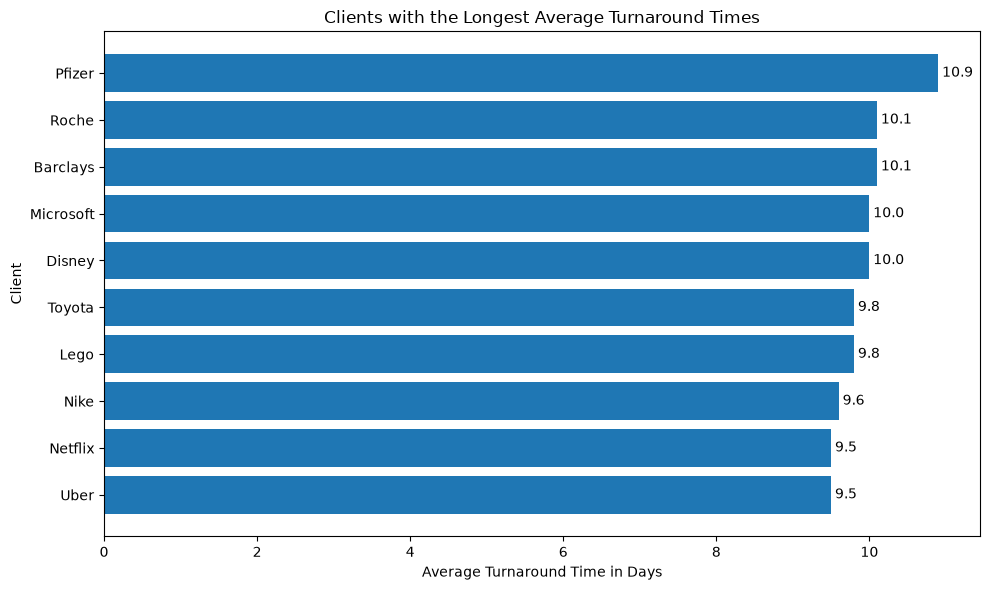

In [690]:
clients_with_longest_turnaround = (
    average_turnaround_by_client
    .nlargest(
        10,
        "average_turnaround_days"
    )
    .sort_values(
        "average_turnaround_days"
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    clients_with_longest_turnaround["client"],
    clients_with_longest_turnaround[
        "average_turnaround_days"
    ]
)

ax.set_title(
    "Clients with the Longest Average Turnaround Times"
)
ax.set_xlabel(
    "Average Turnaround Time in Days"
)
ax.set_ylabel(
    "Client"
)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center"
    )

plt.tight_layout()
plt.show()

#### Key Findings

- Pfizer had the longest average turnaround time at 10.9 days.
- Barclays and Roche both had an average turnaround time of 10.1 days.
- Netflix generated the highest project and word volumes but had a lower average turnaround time of 9.5 days.
- High client volume does not automatically result in the longest delivery schedules.

#### Business Insight

Longer turnaround times do not necessarily indicate poor delivery performance because this measure is based on the planned period between the project start and due dates.

Instead, longer turnaround times may reflect larger, more complex or more carefully scheduled projects.

Pfizer therefore creates a different type of operational demand from Netflix. Netflix generates greater project and translation volume, while Pfizer's projects remain active within the delivery process for longer on average.

Clients with longer-running projects may require more sustained project management oversight, even when they do not generate the highest overall volume.

### Project Type Distribution of High-Volume Clients

Different project types may require different workflows, tools, specialist knowledge and quality processes.

The chart below compares the project type distribution of the five clients with the highest total word volumes.

In [691]:
top_five_clients = (
    client_word_volume
    .nlargest(
        5,
        "total_word_count"
    )["client_name"]
    .tolist()
)

top_client_project_types = (
    client_project_type_breakdown[
        client_project_type_breakdown[
            "client_name"
        ].isin(top_five_clients)
    ]
    .copy()
)

top_client_project_type_pivot = (
    top_client_project_types
    .pivot_table(
        index="client_name",
        columns="project_type",
        values="project_count",
        aggfunc="sum",
        fill_value=0
    )
)

top_client_order = (
    client_word_volume[
        client_word_volume[
            "client_name"
        ].isin(top_five_clients)
    ]
    .sort_values(
        "total_word_count",
        ascending=False
    )["client_name"]
    .tolist()
)

top_client_project_type_pivot = (
    top_client_project_type_pivot
    .reindex(top_client_order)
)

top_client_project_type_pivot

project_type,Documentation,Legal,Marketing,Subtitles,Training,UI
client_name,,,,,,
Netflix,19,18,12,19,15,19
Microsoft,20,17,16,12,17,10
Salesforce,17,14,14,10,14,21
Nike,18,15,15,14,15,15
Amazon,16,15,18,16,15,15


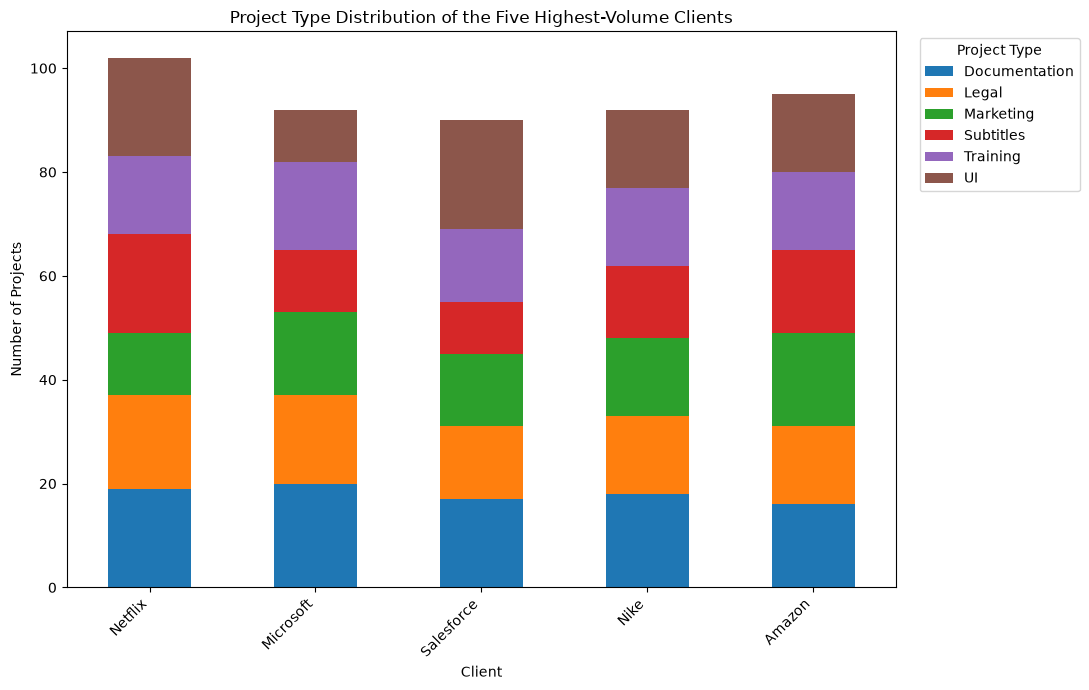

In [692]:
ax = top_client_project_type_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 7)
)

ax.set_title(
    "Project Type Distribution of the Five Highest-Volume Clients"
)
ax.set_xlabel(
    "Client"
)
ax.set_ylabel(
    "Number of Projects"
)

ax.legend(
    title="Project Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

#### Key Findings

- The five highest-volume clients generated work across all available project types rather than relying on one single workflow.
- Documentation was Microsoft's most common project type, with 20 projects.
- Salesforce generated the greatest number of UI projects, with 21.
- Netflix had an even distribution across UI, subtitles and documentation, with 19 projects in each category.
- Marketing was Amazon's most common project type, with 18 projects.
- Documentation was Nike's most common project type, with 18 projects.

#### Business Insight

The highest-volume clients create demand across several different localization workflows.

This means their operational impact is not limited to translation capacity. Supporting these accounts may also require a broad range of technical processes, reviewer expertise and project management knowledge.

Netflix's relatively even distribution across several project types suggests that the business must maintain flexible operational coverage for the account.

Salesforce's higher concentration of UI work may create more specialised demand, such as handling short strings, contextual limitations and product-specific terminology.

Understanding project type distribution can therefore support more targeted resource planning than client volume alone.

## Overall Findings

No single measure fully explains which clients place the greatest operational demand on the business.

Netflix generated both the highest number of projects and the greatest total word volume, making it the strongest overall driver of operational workload.

Microsoft also generated a substantial translation workload despite completing fewer projects than Amazon. This indicates that Microsoft's projects were larger on average and required greater translation capacity per project.

Pfizer did not rank among the highest-volume clients but had the longest average turnaround time. Its projects therefore create a more sustained form of operational demand by remaining active within the delivery process for longer.

The highest-volume clients also generated a broad range of project types, meaning their demand extends beyond project and word counts. These accounts require varied workflows, technical knowledge and specialist resource coverage.

Overall, Netflix and Microsoft place the greatest demand on translation capacity, while clients such as Pfizer create additional operational pressure through longer-running projects. Resource planning should therefore consider project frequency, translation volume, turnaround time and project mix together rather than relying on a single metric.

# 4. Translator Performance

This section examines translator performance across the localization operation.

The analyses focus on evaluating translation quality, delivery performance and language coverage to identify translators who consistently contribute to successful project delivery.


## Business Question

### Which translators consistently deliver the strongest operational performance?

Assessing translator performance requires more than simply counting completed projects. High-performing translators should consistently deliver quality work while maintaining reliable delivery across multiple assignments.

This analysis evaluates translator performance using:

- Average QA score
- QA pass rate
- Reviewed assignment volume
- Total word volume
- Completed project volume
- Performance within individual languages

Together, these measures provide a balanced view of translator contribution across the localization operation.

In [693]:
high_volume_high_quality_translators = run_query(
    "high_volume_high_quality_translators"
)

top_translators_by_language = run_query(
    "top_translators_by_language"
)

completed_projects_by_translator = run_query(
    "completed_projects_by_translator"
)

### High-Volume, High-Quality Translators

To avoid ranking translators using results from very small samples, this analysis includes only translators with at least 10 reviewed assignments.

The chart compares the ten highest-ranked translators based on QA pass rate, with average QA score displayed alongside each result.

In [694]:
top_quality_translators = (
    high_volume_high_quality_translators
    .head(10)
    .sort_values(
        "pass_rate_percentage"
    )
)

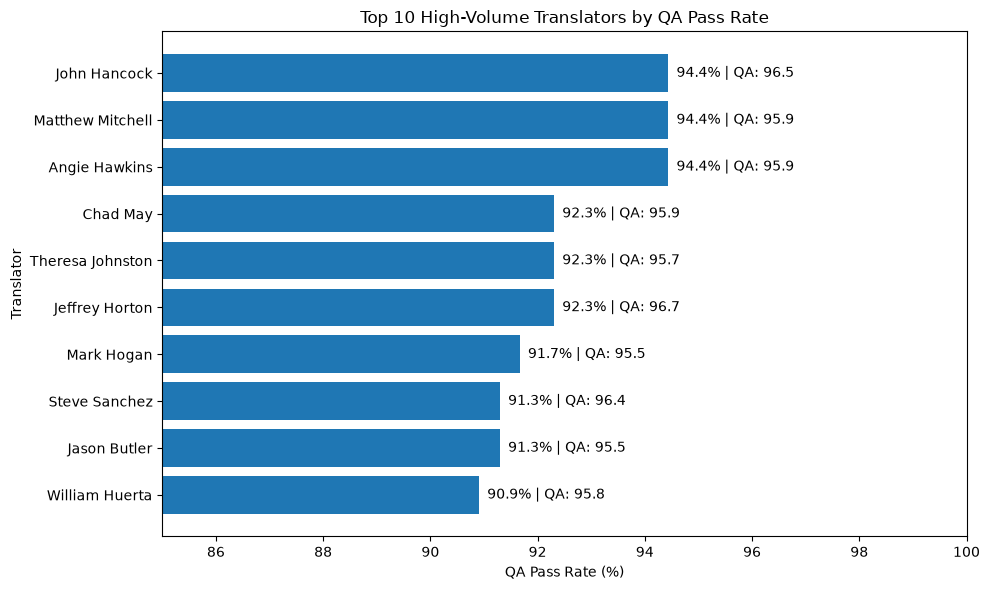

In [695]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_quality_translators["translator_name"],
    top_quality_translators["pass_rate_percentage"]
)

ax.set_title(
    "Top 10 High-Volume Translators by QA Pass Rate"
)
ax.set_xlabel(
    "QA Pass Rate (%)"
)
ax.set_ylabel(
    "Translator"
)

ax.set_xlim(
    85,
    100
)

for bar, qa_score in zip(
    bars,
    top_quality_translators["average_qa_score"]
):
    width = bar.get_width()

    ax.text(
        width + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}% | QA: {qa_score:.1f}",
        va="center"
    )

plt.tight_layout()
plt.show()

#### Key Findings

- John Hancock, Matthew Mitchell and Angie Hawkins achieved the highest QA pass rate among translators with at least 10 reviewed assignments, at 94.44%.
- John Hancock also achieved the highest average QA score among these three translators, at 96.47.
- The strongest results are distributed across several translators rather than being concentrated around one individual.

#### Business Insight

The strongest operational performers are not identified by QA score alone.

John Hancock combines the joint-highest pass rate with a strong average QA score and 18 reviewed assignments, making his results more reliable than those based on only a small number of reviews.

Translators such as Mark Hogan and Jason Butler also demonstrate value by maintaining strong quality across a larger volume of reviewed work.

Using a minimum assignment threshold reduces the risk of overestimating translators whose high scores are based on limited experience.

### Top Translators by Language

Overall translator rankings may hide differences in performance between languages.

This analysis identifies the top three translators within each language based primarily on average QA score. Translators must have at least five reviewed assignments in the language to qualify.

In [696]:
top_translators_language_table = (
    top_translators_by_language[
        [
            "language",
            "language_rank",
            "translator_name",
            "reviewed_assignments",
            "average_qa_score",
            "pass_rate_percentage"
        ]
    ]
    .copy()
)

top_translators_language_table.columns = [
    "Language",
    "Rank",
    "Translator",
    "Reviewed Assignments",
    "Average QA Score",
    "Pass Rate (%)"
]

top_translators_language_table

,Language,Rank,Translator,Reviewed Assignments,Average QA Score,Pass Rate (%)
0,Chinese,1,Dwayne Gilmore,5,98.10,100.00
1,Chinese,2,Rebecca Roberts,11,97.77,100.00
2,Chinese,3,James Bryant,7,97.50,100.00
3,Dutch,1,Danielle Watson,5,95.30,80.00
4,Dutch,2,Paige Carlson,5,95.30,80.00
5,Dutch,3,Kelsey Levine,5,93.80,80.00
6,English,1,Matthew Espinoza,5,97.50,100.00
7,English,2,Robert Miller,5,97.20,100.00
8,English,3,Amy Manning,6,96.25,100.00
9,French,1,Jeffrey Horton,14,96.75,92.86


#### Key Findings

- Dwayne Gilmore ranked first for Chinese with an average QA score of 98.10 and a 100% pass rate.
- Matthew Espinoza ranked first for English with an average QA score of 97.50 and a 100% pass rate.
- Jeffrey Horton ranked first for French with an average QA score of 96.75.
- Nathan Ortiz ranked first for German with an average QA score of 95.94 across 41 reviewed assignments.
- Performance levels and assignment volumes vary considerably between languages.

#### Business Insight

Language-level rankings provide more practical information for project allocation than one overall translator ranking.

A translator may be one of the strongest available resources for a particular language even if they do not appear among the highest performers across the entire business.

Nathan Ortiz is especially notable because his first-place German ranking is supported by 41 reviewed assignments, giving the result a stronger evidence base than rankings based on only five assignments.

These rankings can support more informed translator selection for quality-critical or high-volume work.

### Completed Project Volume by Translator

Completed project volume shows which translators have contributed most frequently to project delivery.

This provides an indication of operational reliance but should be interpreted alongside quality performance.

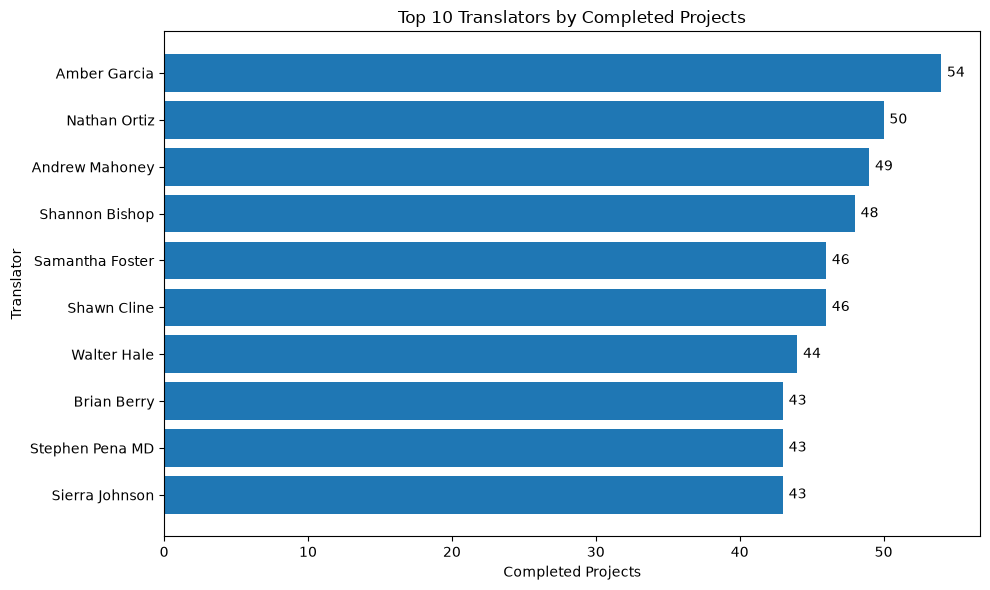

In [697]:
top_translators_by_completed_projects = (
    completed_projects_by_translator
    .head(10)
    .sort_values(
        "projects_completed"
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_translators_by_completed_projects[
        "translator_name"
    ],
    top_translators_by_completed_projects[
        "projects_completed"
    ]
)

ax.set_title(
    "Top 10 Translators by Completed Projects"
)
ax.set_xlabel(
    "Completed Projects"
)
ax.set_ylabel(
    "Translator"
)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

#### Key Findings

- Amber Garcia completed the highest number of projects, with 54.

#### Business Insight

The highest-volume translators represent resources on which the operation relies most frequently.

 High workload may reflect availability, language demand or resource shortages rather than stronger performance.

Operational decisions should therefore balance completed project volume with QA results and language-specific expertise.


## Overall Findings

Translator performance is best evaluated using a combination of quality, consistency and delivery experience.

John Hancock, Matthew Mitchell and Angie Hawkins achieved the highest QA pass rates among translators with at least 10 reviewed assignments. John Hancock also maintained a strong average QA score, making him one of the strongest overall performers within this group.

Language-level analysis provides additional operational context. Dwayne Gilmore and Matthew Espinoza achieved particularly strong results for Chinese and English, while Nathan Ortiz ranked first for German across a much larger number of reviewed assignments.

Nathan Ortiz also completed the second-highest number of projects overall. His combination of strong German QA performance and high project volume suggests that he is both a high-performing and heavily relied-upon operational resource.

Overall, the strongest translators are those who maintain reliable quality across a meaningful volume of work. Performance monitoring should therefore combine QA scores, pass rates, assignment volume and language expertise rather than relying on a single ranking.

# 5. Resource Planning & Operational Risk

This section examines translator coverage and resource allocation across the localization operation.

The analyses focus on identifying potential resource gaps, understanding how translator coverage varies between locales and highlighting areas where operational resilience could be improved.

# Business Question

## Where are the main translator capacity risks?

Effective resource planning requires both sufficient language coverage and appropriate use of available translators.

This analysis considers:

- Project demand relative to translator supply
- Translators with no recorded assignments

In [698]:
locale_supply_and_demand = run_query(
    "locale_supply_and_demand"
)

unassigned_translators = run_query(
    "unassigned_translators"
)

### Project Demand per Translator

Comparing project demand directly with translator supply provides a more meaningful indication of resource pressure than translator counts alone.

Projects per translator measures how many locale-specific project requirements exist for each available translator.

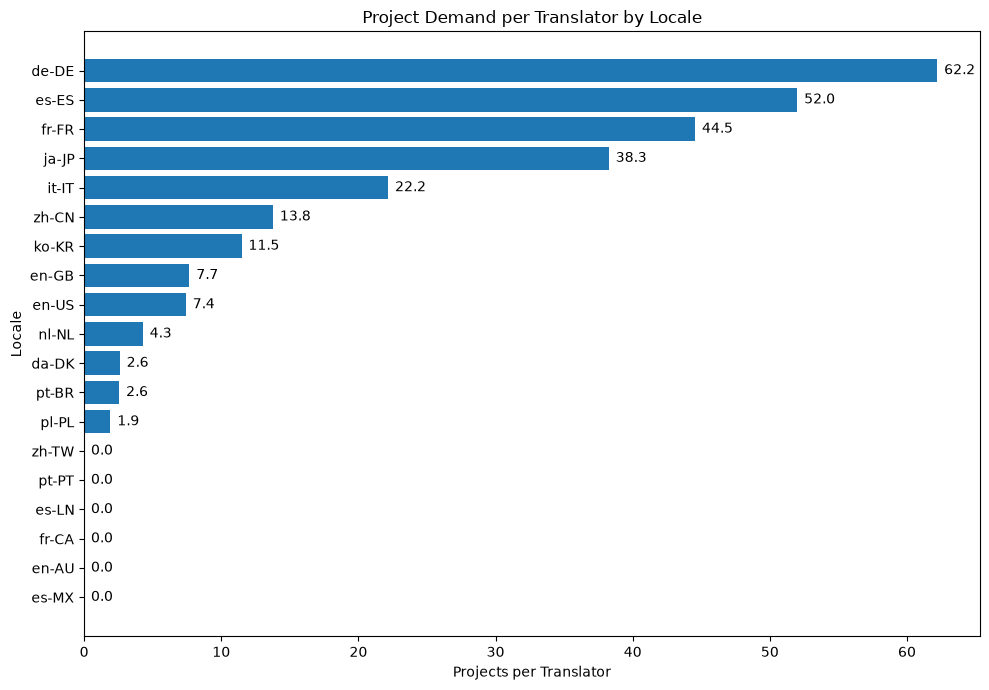

In [699]:
locale_demand_pressure = (
    locale_supply_and_demand
    .sort_values(
        "projects_per_translator",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    locale_demand_pressure["locale_code"],
    locale_demand_pressure["projects_per_translator"]
)

ax.set_title(
    "Project Demand per Translator by Locale"
)
ax.set_xlabel(
    "Projects per Translator"
)
ax.set_ylabel(
    "Locale"
)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center"
    )

plt.tight_layout()
plt.show()

#### Key Findings

- German has the highest project demand per translator, with approximately 62.2 projects for each available translator.
- French (France) has approximately 44.6 projects per translator despite having 40 available translators.
- Translator supply does not consistently increase in line with project demand.

#### Business Insight

German presents the clearest resource risk. Although 29 translators support the locale, they are associated with more than 1,800 locale-specific project requirements.

French has the joint-highest level of translator coverage but still records the third-highest demand per translator. This demonstrates why translator counts should not be assessed without considering the volume of work those resources must support.

German, Spanish, French and Japanese should receive the greatest attention when reviewing supplier capacity or planning for future increases in demand.

### Unassigned Translator Capacity

Translators with no recorded assignments represent unused capacity within the current resource pool.

In [700]:
unassigned_count = len(
    unassigned_translators
)

print(
    f"Translators with no recorded assignments: "
    f"{unassigned_count}"
)

Translators with no recorded assignments: 136


In [701]:
most_experienced_unassigned = (
    unassigned_translators
    .nlargest(
        10,
        "years_experience"
    )
    [
        [
            "translator_name",
            "country",
            "years_experience"
        ]
    ]
    .reset_index(drop=True)
)

most_experienced_unassigned.columns = [
    "Translator",
    "Country",
    "Years of Experience"
]

most_experienced_unassigned

,Translator,Country,Years of Experience
0,Antonio Fry,Australia,30
1,Anthony Rodriguez,Hungary,29
2,Jason Pierce,Cook Islands,29
3,Kristen Willis,Afghanistan,29
4,Brandon Shaffer,Hong Kong,28
5,Brandy Wilson,Netherlands,28
6,Michael Rubio,Nauru,28
7,Michelle Rios,Ghana,28
8,Monica Garcia,Rwanda,27
9,Shannon Ramsey,Haiti,27


#### Key Findings

- 136 translators have no recorded project assignments.
- Antonio Fry is the most experienced unassigned translator, with 30 years of experience.
- Several unassigned translators have more than 25 years of experience.
- Unused capacity exists despite high demand in several locales.

#### Business Insight

Before expanding the supplier pool, the business should determine whether unassigned translators support the highest-pressure locales and have the required specialisations.

Where their skills match demand, using existing resources could improve utilisation and reduce dependency on heavily used translators.

## Overall Findings

Translator capacity is not evenly aligned with project demand.

German, Spanish, French and Japanese experience the greatest demand per translator, while 136 translators have no recorded assignments.

This suggests that the main challenge may not be the total number of translators, but whether available resources are aligned with the languages and specialisations generating the most work.